In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
#URL = 'https://github.com/aiedu-courses/stepik_eda_and_dev_tools/blob/main/datasets/abalone.csv'
URL = 'abalone.csv'

df = pd.read_csv(URL)
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,NaN,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


**Исследование данных**

размер таблицы

In [58]:
df.shape

(4177, 9)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4078 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4078 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4127 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


Есть пропуски в колонках: Diameter, Whole weight, Shell weight

In [60]:
df['Diameter'].isna().sum()

np.int64(99)

In [61]:
df['Whole weight'].isna().sum()

np.int64(99)

In [62]:
df['Shell weight'].isna().sum()

np.int64(50)

доля строк с пропущенными значениями

In [63]:
null_rows = df[df.isnull().any(axis=1)]
len(null_rows) / len(df)

0.057936317931529806

In [64]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4078.000000,4177.000000,4078.000000,4177.000000,4177.000000,4127.000000,4177.000000
mean,0.523992,0.407840,0.139516,0.827306,0.359367,0.180594,0.239072,9.933684
std,0.120093,0.099286,0.041827,0.490348,0.221963,0.109614,0.138942,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.440500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.798500,0.336000,0.171000,0.235000,9.000000
75%,0.615000,0.480000,0.165000,1.150875,0.502000,0.253000,0.328250,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [65]:
df.describe(include='object')

,Sex
count,4177
unique,4
top,M
freq,1447


Проверка дублей

In [66]:
df.duplicated().sum()

np.int64(0)

Датасет состоит из 4177 строк и 9 признаков. Типы данных: 1 категориальный, 7 вещественных, 1 целочисленный. В трех столбцах (Diameter, Whole weight, Shell weight) найдены пропуски (~5.8% данных), полных дубликатов нет

**Работа с пропущенными значениями**

In [67]:
df['Whole weight'] = df['Whole weight'].fillna(df['Whole weight'].median())
df['Diameter'] = df['Diameter'].fillna(df['Diameter'].median())
df['Shell weight'] = df['Shell weight'].fillna(df['Shell weight'].median())

In [68]:
df.isna().sum()

,0
Sex,0
Length,0
Diameter,0
Height,0
Whole weight,0
Shucked weight,0
Viscera weight,0
Shell weight,0
Rings,0


Проверим еще раз дубли

In [69]:
df.duplicated().sum()

np.int64(0)

**Однофакторный анализ**

In [70]:
list(df.columns)

['Sex',
 'Length',
 'Diameter',
 'Height',
 'Whole weight',
 'Shucked weight',
 'Viscera weight',
 'Shell weight',
 'Rings']

In [71]:
df.Sex.value_counts()

,count
Sex,
M,1447
I,1276
F,1259
f,195


In [72]:
#Значение 'f' и 'F' - одно и тоже, нужно объединить
df.Sex = df.Sex.replace('f', 'F')
df.Sex.value_counts()

,count
Sex,
F,1454
M,1447
I,1276


<Axes: xlabel='Sex', ylabel='count'>

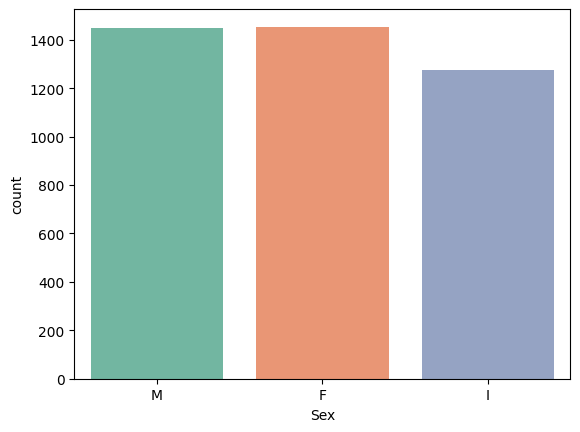

In [73]:
sns.countplot(data=df, x='Sex', hue='Sex', palette='Set2')

In [74]:
# список числовых признаков
numeric_columns = df.select_dtypes(exclude='object').columns
print(list(numeric_columns))

['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']


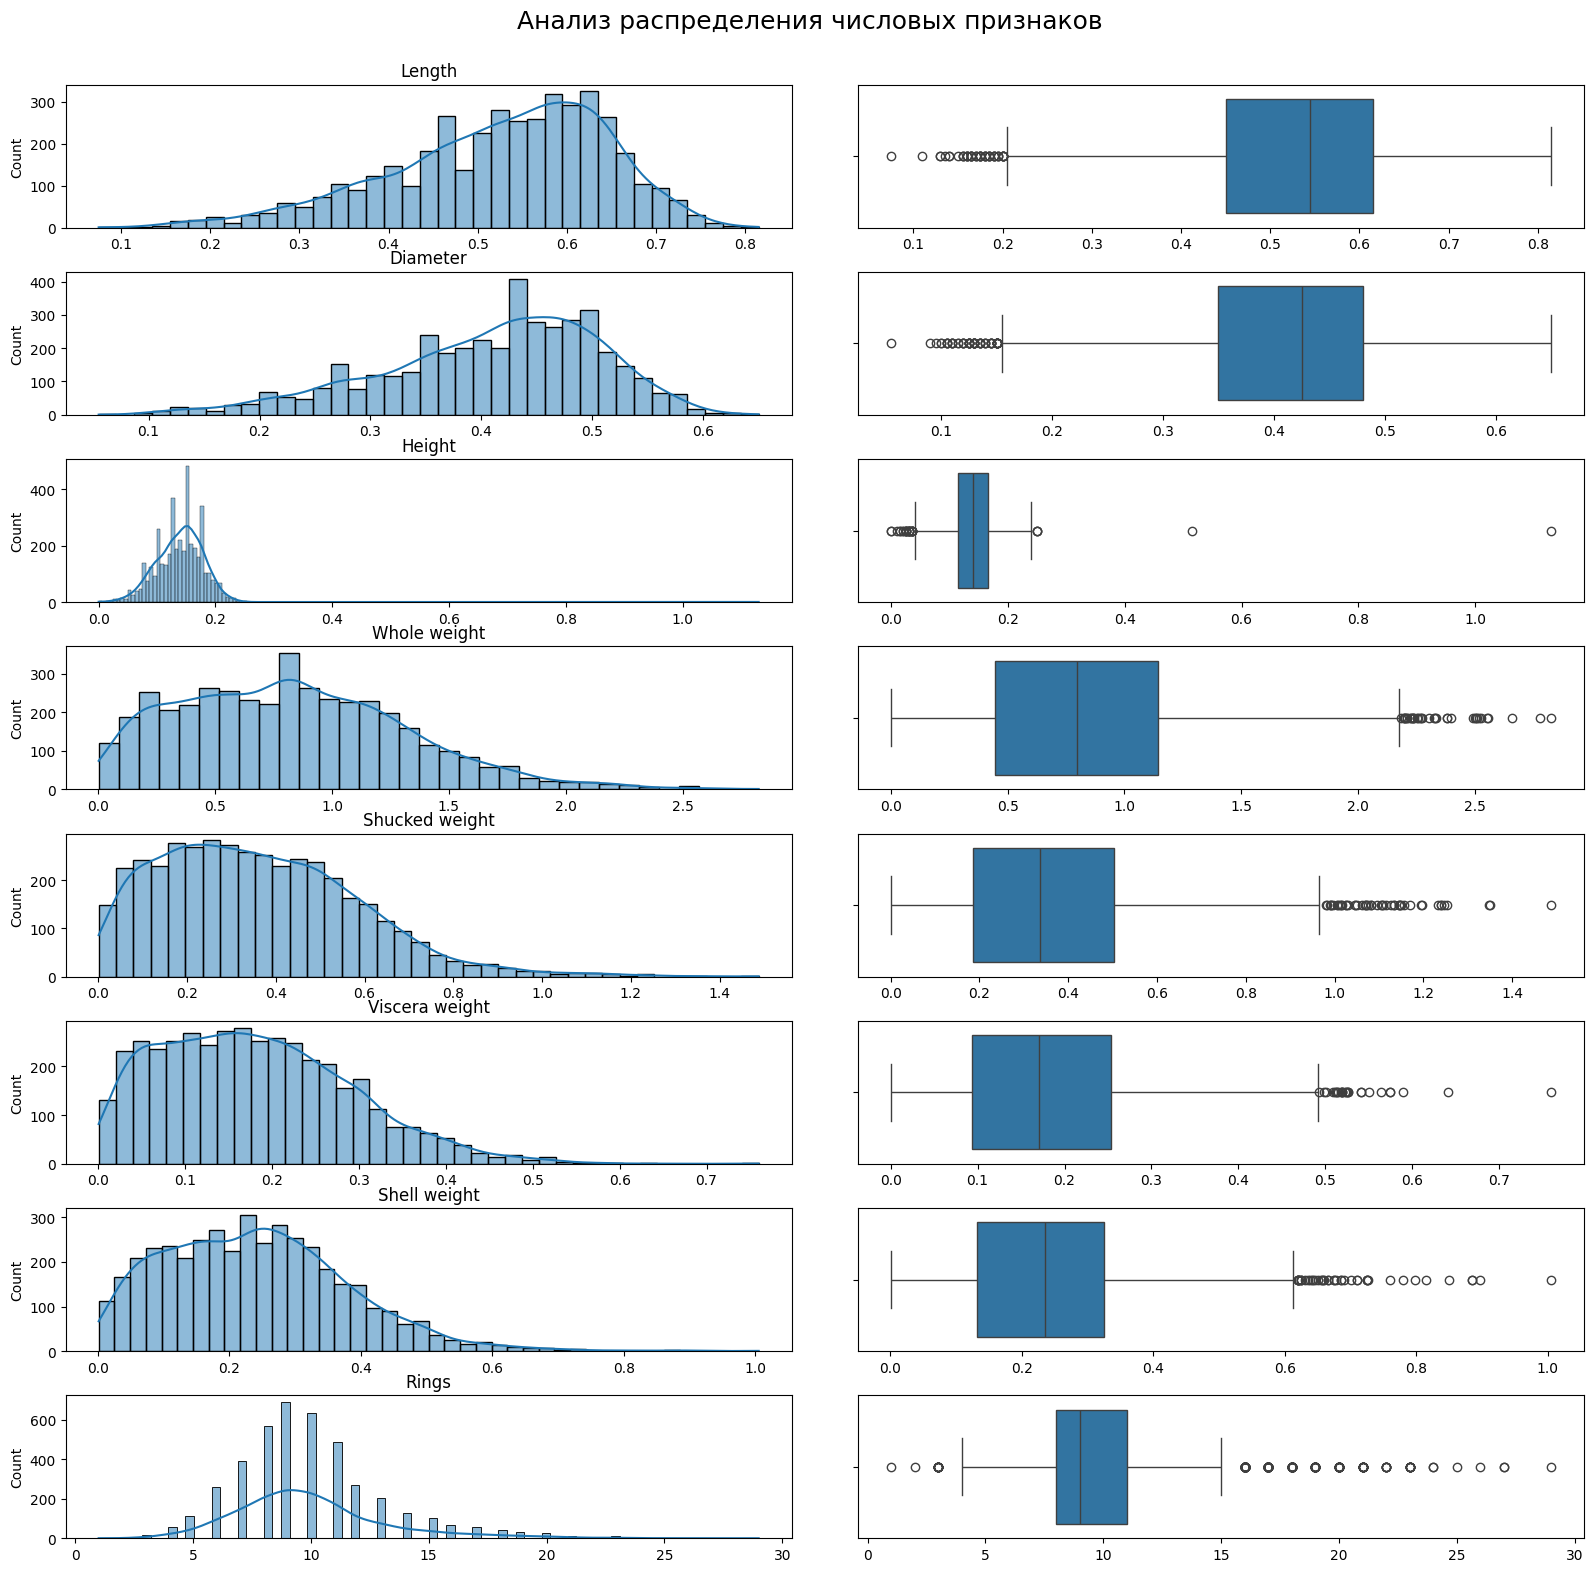

In [75]:
fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(16,16))
fig.suptitle('Анализ распределения числовых признаков', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
for i, col in enumerate(numeric_columns):
  sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0])
  sns.boxplot(data=df, x=col, ax=axes[i, 1])
  axes[i, 0].set_title(f'{col}', fontsize=12)
  axes[i, 0].set_xlabel('')
  axes[i, 1].set_xlabel('')


**Length, Diameter**
Распределение примерно нормальное с небольшим скосом влево, выбросов почти нет.

**Height**
Очень скошенное распределение с большим количеством очень маленьких значений и выбросами справа.

**Whole weight, Shucked weight, Viscera weight, Shell weight**
Распределение с длинным хвостом вправо и явными выбросами (точки за усами на боксплотах).

В биологических данных (как Abalone) выбросы — это настоящие редкие случаи, которые могут быть важными.


**Анализ распределения целевой переменной**


**Rings (целевая переменная)**
Распределение колоколообразное, но с выбросами — несколько абалонов с необычно большим возрастом.

Распределение является унимодальным (имеет один ярко выраженный пик в районе 9–10) и имеет сильную правостороннюю асимметрию. Длинный «хвост» уходит вправо вплоть до значения 29. Визуально оно очень похоже на логнормальное распределение.

Из-за длинного правого хвоста и выбросов стандартные алгоритмы (Linear regression) будут излишне подстраиваться под редкие экстремальные значения, что приведет к падению точности на основной массе данных и систематическому занижению прогнозов для объектов из этого самого "хвоста".

**Взаимозависимость в данных**

In [76]:
df.corr(numeric_only=True)

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Length,1.000000,0.974693,0.827554,0.915426,0.897914,0.903018,0.889517,0.556720
Diameter,0.974693,1.000000,0.823014,0.906350,0.882375,0.888190,0.885752,0.563512
Height,0.827554,0.823014,1.000000,0.811451,0.774972,0.798319,0.809684,0.557467
Whole weight,0.915426,0.906350,0.811451,1.000000,0.957427,0.954036,0.934197,0.532149
Shucked weight,0.897914,0.882375,0.774972,0.957427,1.000000,0.931961,0.874333,0.420884
Viscera weight,0.903018,0.888190,0.798319,0.954036,0.931961,1.000000,0.899098,0.503819
Shell weight,0.889517,0.885752,0.809684,0.934197,0.874333,0.899098,1.000000,0.622194
Rings,0.556720,0.563512,0.557467,0.532149,0.420884,0.503819,0.622194,1.000000


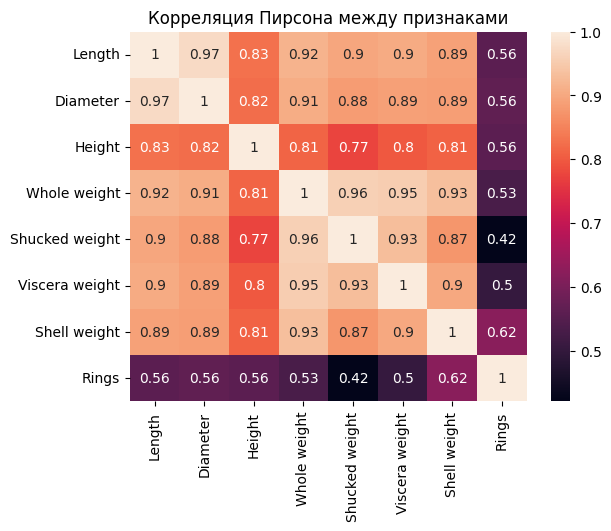

In [77]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Корреляция Пирсона между признаками")
plt.show()

Поскольку в признаках есть большие выбросы, посмотрим корреляция Спирмана

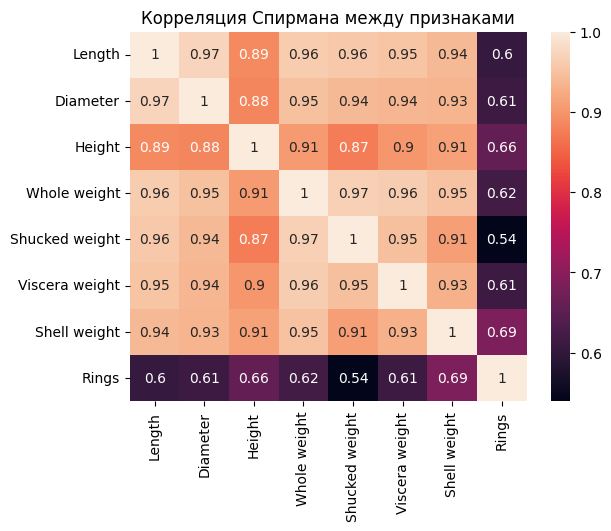

In [78]:
sns.heatmap(df.corr(numeric_only=True, method='spearman'), annot=True)
plt.title("Корреляция Спирмана между признаками")
plt.show()

Мы видим большие значения корреляции между всеми физическими размерами и весовыми характеристиками.

Умеренная связь с целевой переменной (Rings): Ни один из признаков не имеет идеальной связи с возрастом. Самый сильный предиктор из одиночных признаков — это Shell weight. Слабее всего с возрастом связан Shucked weight.

**Связь признаков с целевой переменной**

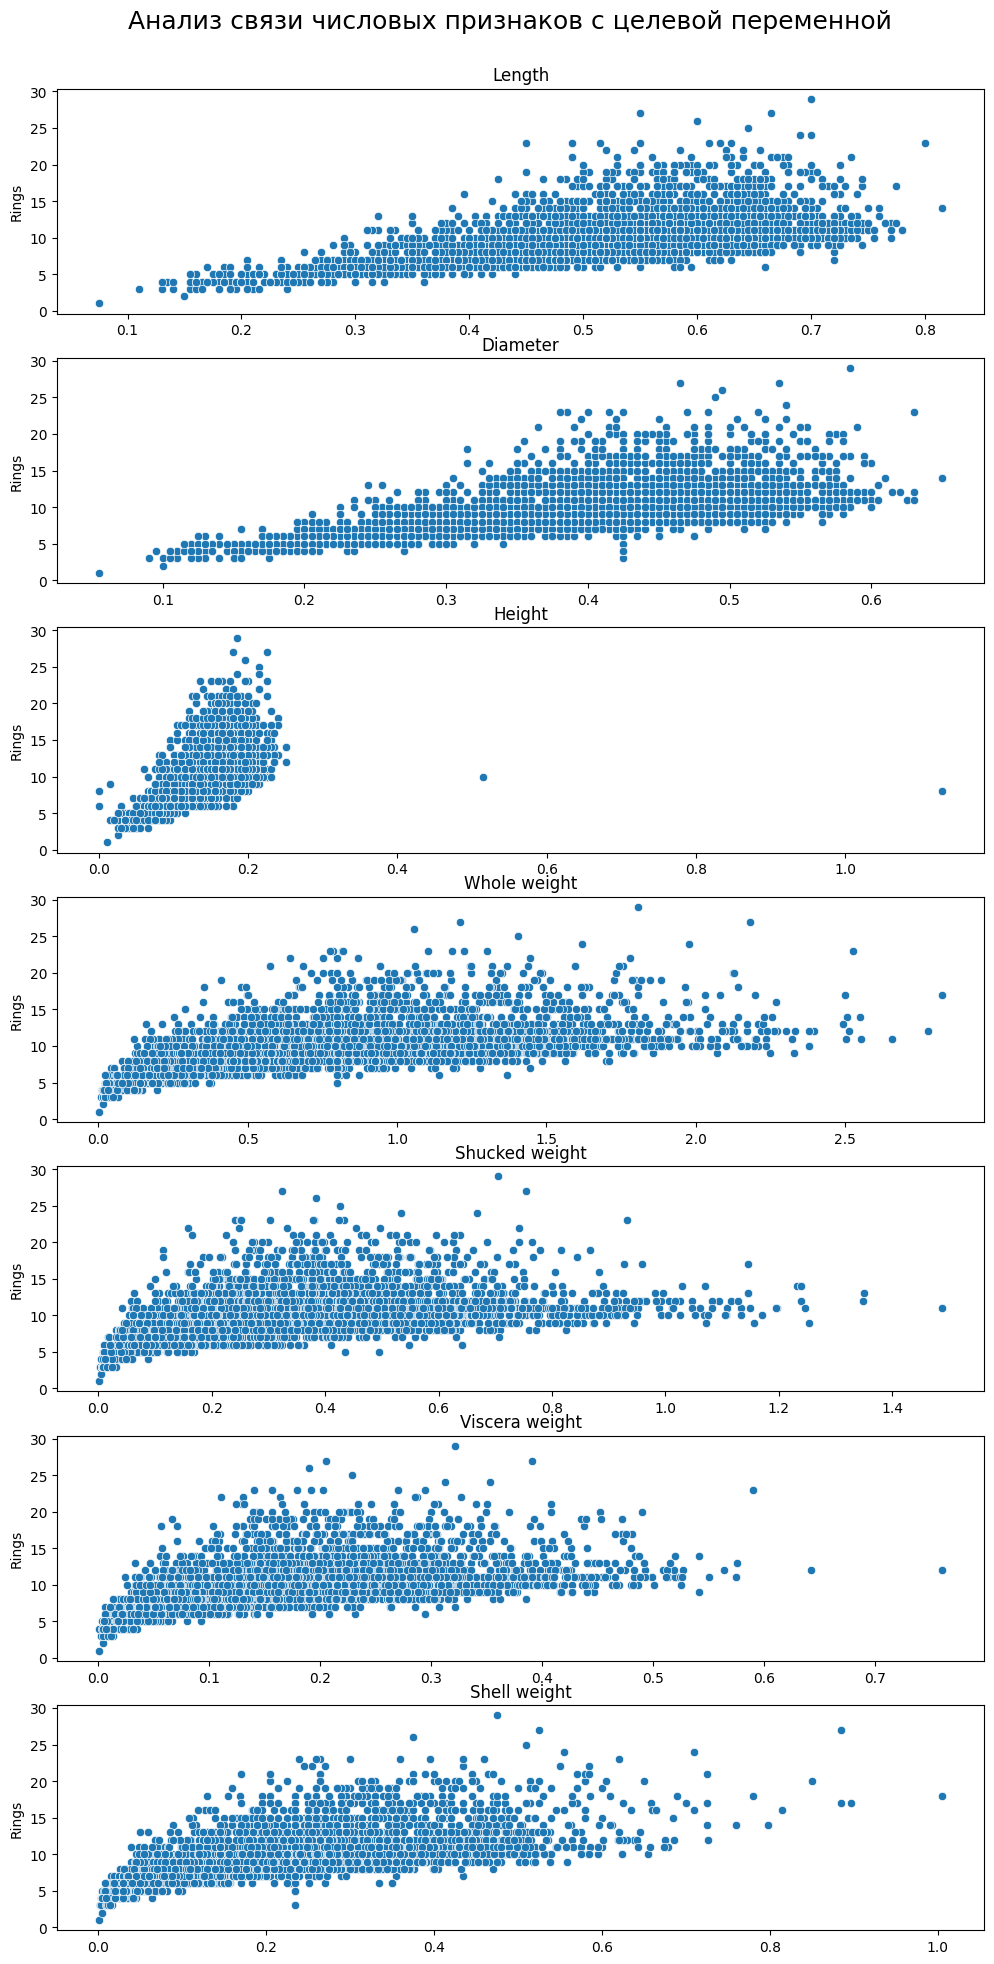

In [79]:
target = 'Rings'
numeric_columns = df.select_dtypes(include=np.float64).columns
fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(10,20))
fig.suptitle('Анализ связи числовых признаков с целевой переменной', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
for i, col in enumerate(numeric_columns):
  sns.scatterplot(data=df, x=col, y=target, ax=axes[i])
  axes[i].set_title(f'{col}', fontsize=12)
  axes[i].set_xlabel('')

Прямая связь: Все физические параметры увеличиваются вместе с возрастом (количеством колец).
Сила влияния: Лучше всего возраст предсказывают вес раковины (0.69) и высота (0.66), хуже всего — вес самого мяса (0.54).
У мелких моллюсков разброс возраста минимален, и предсказать его легко. Но чем крупнее особь, тем сильнее становится разброс возможных значений возраста.

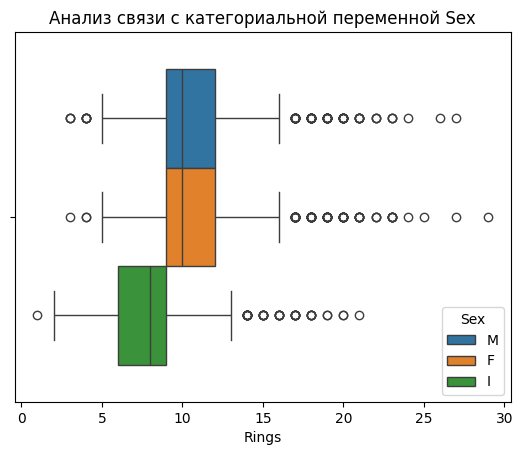

In [80]:
#fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(12,12))
sns.boxplot(data=df, x=target, hue='Sex')
plt.title("Анализ связи с категориальной переменной Sex")
plt.show()

Явное отличие детенышей: Категория I (Infant) имеет заметно меньшее количество колец. Медиана и основной размах лежат левее, что помогает легко отделять молодых особей.
Сходство взрослых особей: Распределения для самцов (M) и самок (F) практически идентичны. У них совпадают медианы (около 10 колец) и межквартильные размахи.

**ANOVA**

In [81]:
from scipy.stats import f_oneway

col = 'Sex'
print("Корреляция с признаком:", col)
result = []
for num_col in numeric_columns:
  category_grouplist = df.groupby(col)[num_col].apply(list)
  anova_result = f_oneway(*category_grouplist)
  row = {}
  row['column'] = num_col
  row['p-value'] = anova_result.pvalue
  row['correlated'] = (anova_result.pvalue < 0.05)
  result.append(row)
pd.DataFrame(result)

Корреляция с признаком: Sex


,column,p-value,correlated
0,Length,8.366338e-308,True
1,Diameter,1.711956e-315,True
2,Height,1.109013e-265,True
3,Whole weight,1.378586e-303,True
4,Shucked weight,1.502737e-267,True
5,Viscera weight,5.442072e-312,True
6,Shell weight,1.558861e-294,True


вывод: колонка Sex статистически значимо влияет на все физические характеристики и возраст (Rings)

**Polars**

In [82]:
import polars as pl

df_big = df.copy()
while df_big.shape[0] < 1_000_000:
  df_big = pd.concat([df_big, df])
print(df_big.shape)
name_big_file = "abalone_big.csv"
df_big.to_csv(name_big_file, index=False)

(1002480, 9)


чтение данных

In [83]:
%%time

df_pl = pl.read_csv(name_big_file)

CPU times: user 782 ms, sys: 289 ms, total: 1.07 s
Wall time: 550 ms


In [84]:
%%time

df_pd = pd.read_csv(name_big_file)

CPU times: user 693 ms, sys: 125 ms, total: 818 ms
Wall time: 820 ms


фильтрация данных

In [85]:
%%time

df_pl[['Sex', 'Length']]

CPU times: user 814 µs, sys: 0 ns, total: 814 µs
Wall time: 767 µs


Sex,Length
str,f64
"""M""",0.455
"""M""",0.35
"""F""",0.53
"""M""",0.44
"""I""",0.33
…,…
"""F""",0.565
"""M""",0.59
"""M""",0.6


In [86]:
%%time

df_pd[['Sex', 'Length']]

CPU times: user 14.5 ms, sys: 0 ns, total: 14.5 ms
Wall time: 14.3 ms


,Sex,Length
0,M,0.455
1,M,0.350
2,F,0.530
3,M,0.440
4,I,0.330
...,...,...
1002475,F,0.565
1002476,M,0.590
1002477,M,0.600
1002478,F,0.625


In [87]:
%%time

df_pd.query("Sex == 'M'")

CPU times: user 56.6 ms, sys: 0 ns, total: 56.6 ms
Wall time: 57.2 ms


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
3,M,0.440,0.365,0.125,0.7985,0.2155,0.1140,0.1550,10
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.1650,9
11,M,0.430,0.350,0.110,0.4060,0.1675,0.0810,0.1350,10
...,...,...,...,...,...,...,...,...,...
1002473,M,0.550,0.430,0.130,0.8395,0.3155,0.1955,0.2405,10
1002474,M,0.560,0.430,0.155,0.8675,0.4000,0.1720,0.2290,8
1002476,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
1002477,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9


In [88]:
%%time

df_pl.filter(pl.col('Sex') == 'M')

CPU times: user 27.6 ms, sys: 30.9 ms, total: 58.5 ms
Wall time: 33.9 ms


Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
str,f64,f64,f64,f64,f64,f64,f64,i64
"""M""",0.455,0.365,0.095,0.514,0.2245,0.101,0.15,15
"""M""",0.35,0.265,0.09,0.2255,0.0995,0.0485,0.07,7
"""M""",0.44,0.365,0.125,0.7985,0.2155,0.114,0.155,10
"""M""",0.475,0.37,0.125,0.5095,0.2165,0.1125,0.165,9
"""M""",0.43,0.35,0.11,0.406,0.1675,0.081,0.135,10
…,…,…,…,…,…,…,…,…
"""M""",0.55,0.43,0.13,0.8395,0.3155,0.1955,0.2405,10
"""M""",0.56,0.43,0.155,0.8675,0.4,0.172,0.229,8
"""M""",0.59,0.44,0.135,0.966,0.439,0.2145,0.2605,10


агрегация данных

In [89]:
%%time

df_pd.groupby('Sex').agg({'Rings': 'mean', 'Diameter': 'max'})

CPU times: user 73.1 ms, sys: 22 ms, total: 95 ms
Wall time: 94.5 ms


,Rings,Diameter
Sex,,
F,11.001376,0.65
I,7.872257,0.55
M,10.678645,0.63


In [90]:
%%time

df_pl.group_by('Sex').agg([pl.mean('Rings'), pl.max('Diameter')])

CPU times: user 74.3 ms, sys: 1.05 ms, total: 75.4 ms
Wall time: 41.5 ms


Sex,Rings,Diameter
str,f64,f64
"""F""",11.001376,0.65
"""I""",7.872257,0.55
"""M""",10.678645,0.63


In [91]:
%%time

q = df_pl.lazy().group_by('Sex').agg([pl.mean('Rings'), pl.max('Diameter')])
q.collect()

CPU times: user 73.3 ms, sys: 6.97 ms, total: 80.2 ms
Wall time: 45.4 ms


Sex,Rings,Diameter
str,f64,f64
"""M""",10.678645,0.63
"""I""",7.872257,0.55
"""F""",11.001376,0.65


На увеличенном наборе данных библиотека Polars продемонстрировала стабильное преимущество в скорости по сравнению с Pandas. Этот выигрыш во времени наблюдается на всех ключевых этапах обработки.
Этот результат подтверждает, что при масштабировании объема данных архитектура Polars начинает работать эффективнее классического Pandas, экономя время на базовых операциях.